In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

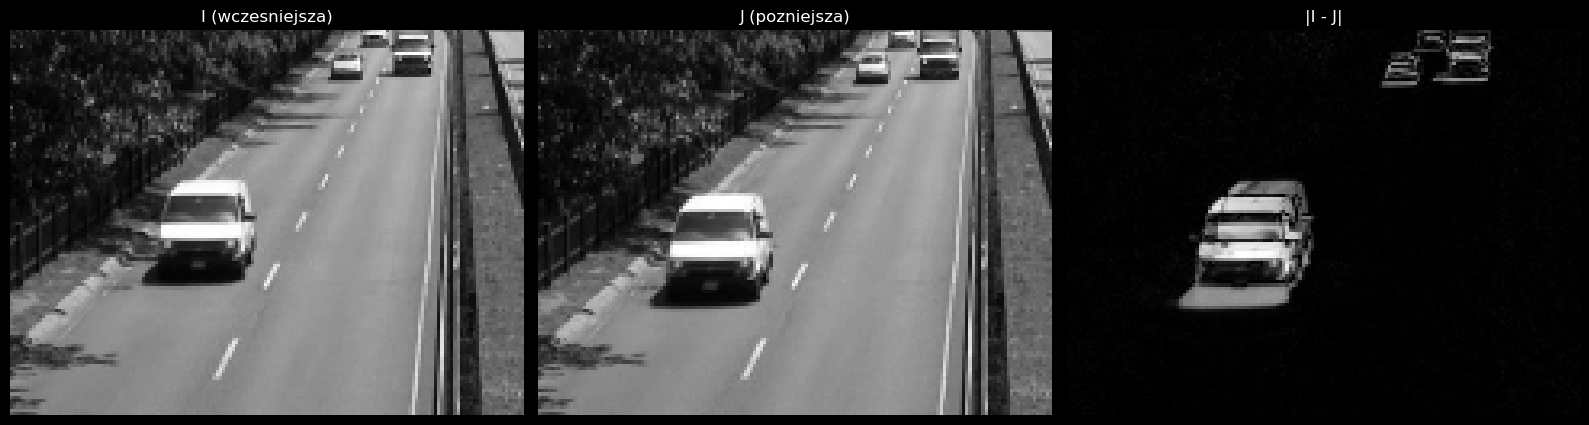

In [43]:
scale = 2

I = cv2.imread("./Materiały-20260415/I.jpg", cv2.IMREAD_GRAYSCALE)
J = cv2.imread("./Materiały-20260415/J.jpg", cv2.IMREAD_GRAYSCALE)

if scale > 1:
    I = cv2.resize(I, (I.shape[1] // scale, I.shape[0] // scale))
    J = cv2.resize(J, (J.shape[1] // scale, J.shape[0] // scale))

diff = cv2.absdiff(I, J)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(I, cmap="gray")
ax[0].set_title("I (wczesniejsza)")
ax[0].axis("off")

ax[1].imshow(J, cmap="gray")
ax[1].set_title("J (pozniejsza)")
ax[1].axis("off")

ax[2].imshow(diff, cmap="gray")
ax[2].set_title("|I - J|")
ax[2].axis("off")

plt.tight_layout()

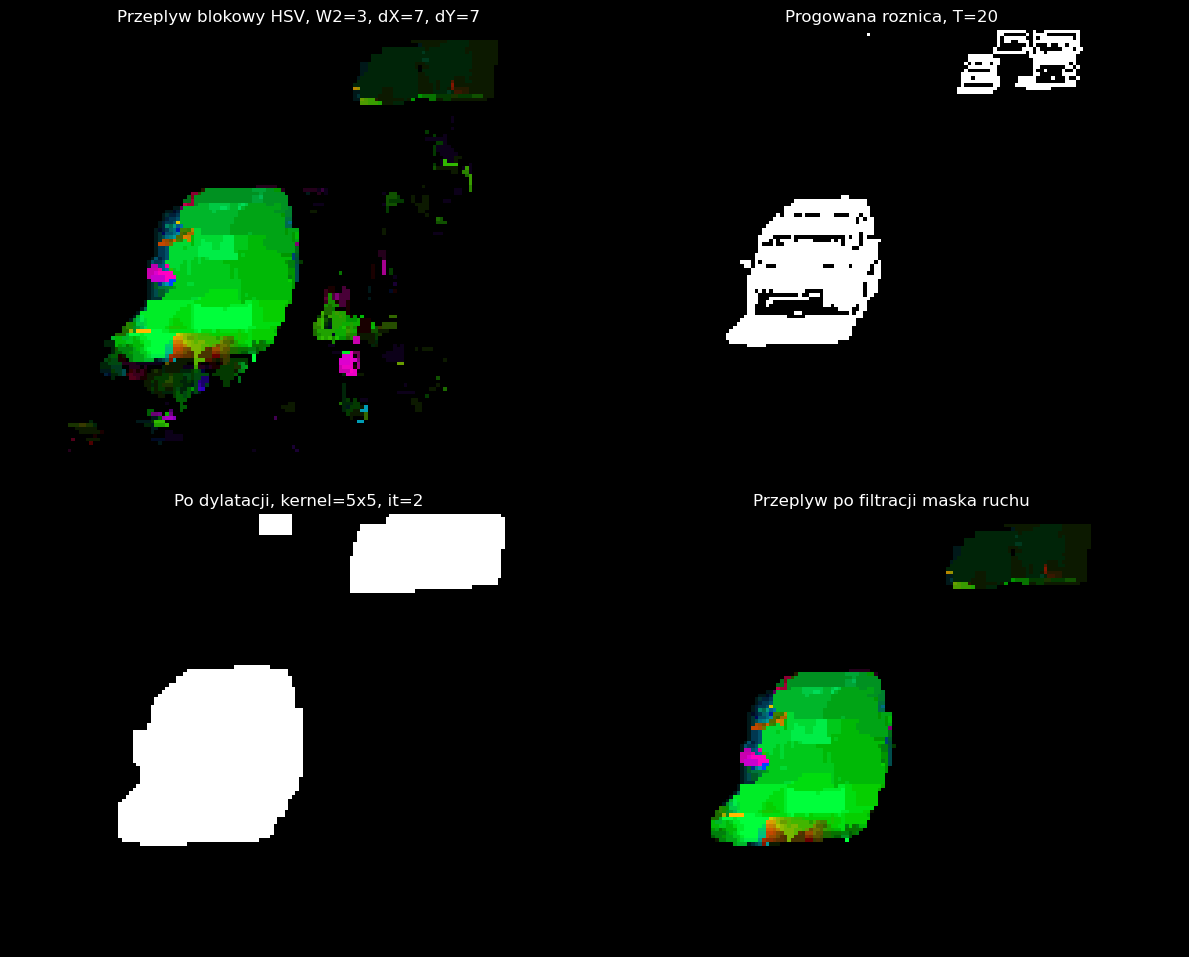

In [44]:
def block_optical_flow(I, J, W2=3, dX=3, dY=3):
    h, w = I.shape
    u = np.zeros((h, w), dtype=np.float32)
    v = np.zeros((h, w), dtype=np.float32)
    min_dist_map = np.full((h, w), np.inf, dtype=np.float32)

    for y in range(W2, h - W2):
        for x in range(W2, w - W2):
            IO = np.float32(I[y - W2:y + W2 + 1, x - W2:x + W2 + 1])

            best_dist = np.inf
            best_dx = 0
            best_dy = 0

            for dy in range(-dY, dY + 1):
                for dx in range(-dX, dX + 1):
                    yy = y + dy
                    xx = x + dx

                    if yy - W2 < 0 or yy + W2 >= h or xx - W2 < 0 or xx + W2 >= w:
                        continue

                    JO = np.float32(J[yy - W2:yy + W2 + 1, xx - W2:xx + W2 + 1])
                    dist = np.sqrt(np.sum(np.square(JO - IO)))

                    if dist < best_dist:
                        best_dist = dist
                        best_dx = dx
                        best_dy = dy

            u[y, x] = best_dx
            v[y, x] = best_dy
            min_dist_map[y, x] = best_dist

    return u, v, min_dist_map


def flow_to_rgb(u, v):
    mag, ang = cv2.cartToPolar(u, v, angleInDegrees=False)

    hsv = np.zeros((u.shape[0], u.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = (ang * 90 / np.pi).astype(np.uint8)

    mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    hsv[..., 1] = 255
    hsv[..., 2] = mag_norm.astype(np.uint8)

    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return rgb

W2 = 3
dX = 7
dY = 7

u, v, min_dist = block_optical_flow(I, J, W2=W2, dX=dX, dY=dY)
flow_rgb = flow_to_rgb(u, v)

threshold = 20
kernel_size = 5
dilate_iter = 2

_, diff_bin = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
kernel = np.ones((kernel_size, kernel_size), np.uint8)
diff_dil = cv2.dilate(diff_bin, kernel, iterations=dilate_iter)

u_f = np.where(diff_dil > 0, u, 0)
v_f = np.where(diff_dil > 0, v, 0)
flow_rgb_f = flow_to_rgb(u_f, v_f)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].imshow(flow_rgb)
ax[0, 0].set_title(f"Przeplyw blokowy HSV, W2={W2}, dX={dX}, dY={dY}")
ax[0, 0].axis("off")

ax[0, 1].imshow(diff_bin, cmap="gray")
ax[0, 1].set_title(f"Progowana roznica, T={threshold}")
ax[0, 1].axis("off")

ax[1, 0].imshow(diff_dil, cmap="gray")
ax[1, 0].set_title(f"Po dylatacji, kernel={kernel_size}x{kernel_size}, it={dilate_iter}")
ax[1, 0].axis("off")

ax[1, 1].imshow(flow_rgb_f)
ax[1, 1].set_title("Przeplyw po filtracji maska ruchu")
ax[1, 1].axis("off")

plt.tight_layout()

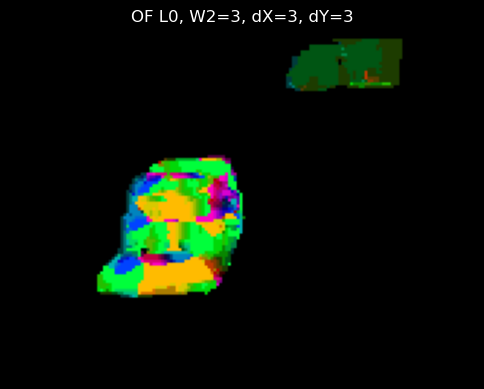

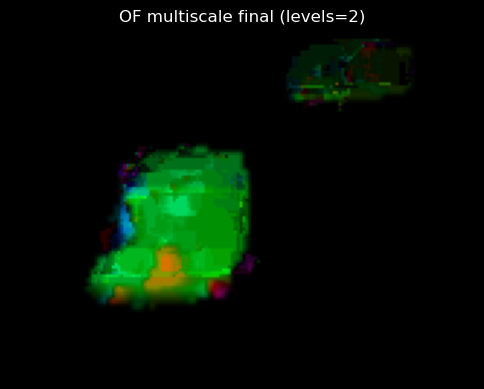

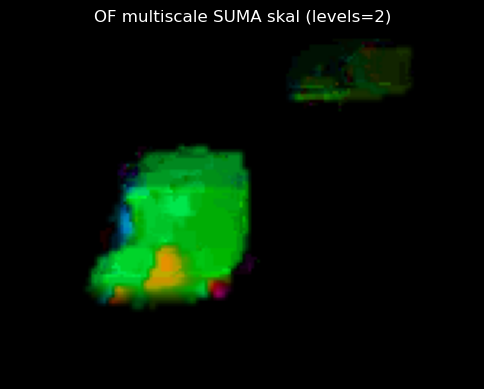

Czas L0: 2.21 s
Czas multi (levels=2): 2.76 s
Eksperymenty: zmien levels, W2, dX, dY oraz scale w cellu 2.


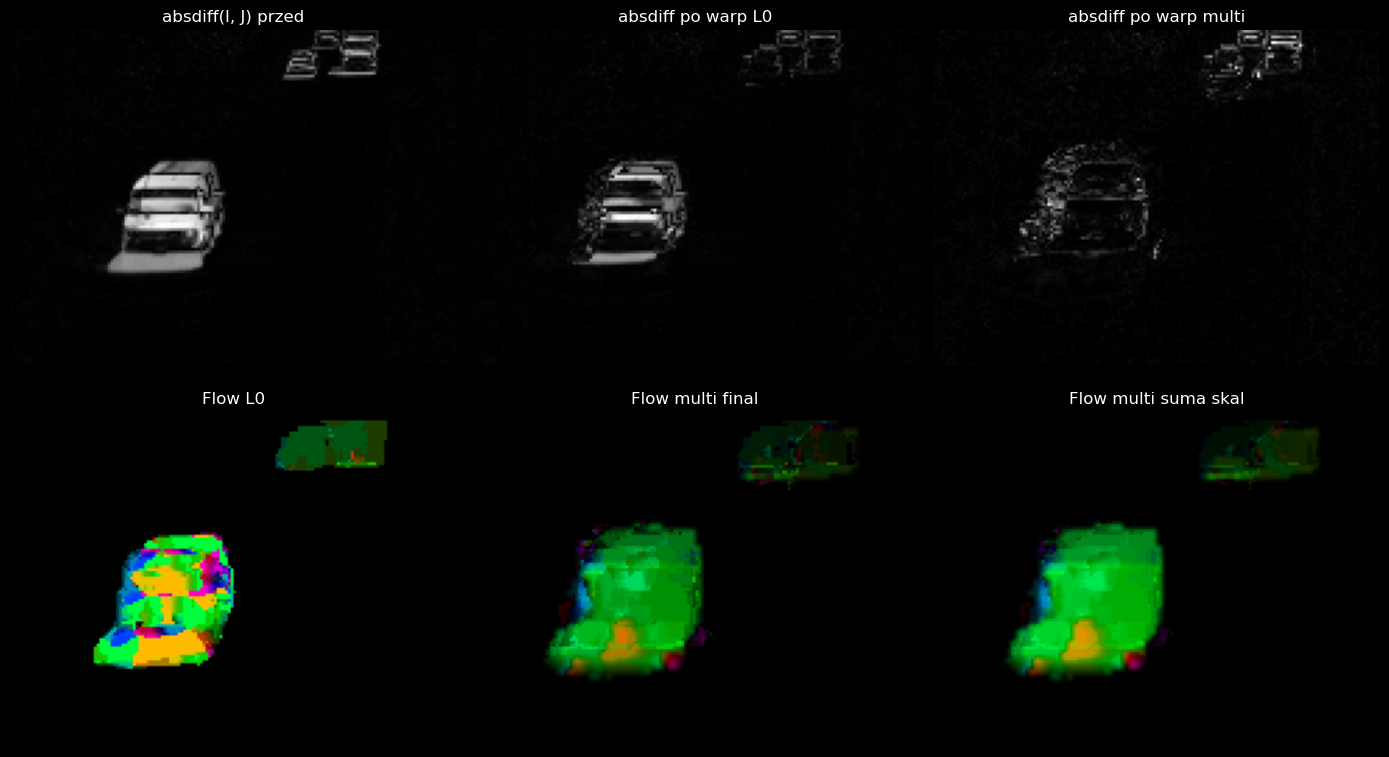

In [45]:
import time

def vis_flow(u, v, YX, name="flow"):
    mag, ang = cv2.cartToPolar(u, v, angleInDegrees=False)

    hsv = np.zeros((YX[0], YX[1], 3), dtype=np.uint8)
    hsv[..., 0] = (ang * 90 / np.pi).astype(np.uint8)
    mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    hsv[..., 1] = 255
    hsv[..., 2] = mag_norm.astype(np.uint8)

    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(name)
    plt.axis("off")
    plt.show()
    return rgb

def pyramid(im, max_scale):
    images = [im]
    for _ in range(1, max_scale):
        images.append(cv2.resize(images[-1], (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR))
    return images

def warp_by_flow(J, u, v):
    h, w = J.shape
    J_new = np.zeros_like(J)
    for y in range(h):
        for x in range(w):
            xx = int(round(x + u[y, x]))
            yy = int(round(y + v[y, x]))
            if 0 <= xx < w and 0 <= yy < h:
                J_new[y, x] = J[yy, xx]
    return J_new

def of(J_org, I, J, W2=3, dY=3, dX=3, do_filter=True, thr=20, kernel_size=5, dilate_iter=2, show=False):
    u, v, min_dist = block_optical_flow(I, J, W2=W2, dX=dX, dY=dY)

    if do_filter:
        diff = cv2.absdiff(I, J)
        _, diff_bin = cv2.threshold(diff, thr, 255, cv2.THRESH_BINARY)
        kernel = np.ones((kernel_size, kernel_size), np.uint8)
        diff_dil = cv2.dilate(diff_bin, kernel, iterations=dilate_iter)
        u = np.where(diff_dil > 0, u, 0)
        v = np.where(diff_dil > 0, v, 0)

    if show:
        diff_org = cv2.absdiff(I, J_org)
        diff_now = cv2.absdiff(I, J)
        fig, ax = plt.subplots(1, 4, figsize=(16, 4))
        ax[0].imshow(I, cmap="gray")
        ax[0].set_title("I")
        ax[0].axis("off")
        ax[1].imshow(J_org, cmap="gray")
        ax[1].set_title("J_org")
        ax[1].axis("off")
        ax[2].imshow(J, cmap="gray")
        ax[2].set_title("J (aktualne)")
        ax[2].axis("off")
        ax[3].imshow(np.hstack([diff_org, diff_now]), cmap="gray")
        ax[3].set_title("absdiff: [I-J_org | I-J]")
        ax[3].axis("off")
        plt.tight_layout()

    return u, v, min_dist

def multiscale_of(I0, J0, levels=2, W2=3, dX=3, dY=3, do_filter=True):
    IP = pyramid(I0, levels)
    JP = pyramid(J0, levels)

    u_init = np.zeros_like(IP[-1], dtype=np.float32)
    v_init = np.zeros_like(IP[-1], dtype=np.float32)
    per_scale = []

    for s in range(levels - 1, -1, -1):
        I_s = IP[s]
        J_s_org = JP[s]
        J_s = warp_by_flow(J_s_org, u_init, v_init)

        u_res, v_res, _ = of(J_s_org, I_s, J_s, W2=W2, dX=dX, dY=dY, do_filter=do_filter)
        u_total = u_init + u_res
        v_total = v_init + v_res
        per_scale.append((s, u_total.copy(), v_total.copy()))

        if s > 0:
            next_h, next_w = IP[s - 1].shape
            u_init = cv2.resize(2.0 * u_total, (next_w, next_h), interpolation=cv2.INTER_LINEAR)
            v_init = cv2.resize(2.0 * v_total, (next_w, next_h), interpolation=cv2.INTER_LINEAR)
        else:
            u_init = u_total
            v_init = v_total

    h0, w0 = I0.shape
    u_sum = np.zeros((h0, w0), dtype=np.float32)
    v_sum = np.zeros((h0, w0), dtype=np.float32)

    for s, u_s, v_s in per_scale:
        factor = 2 ** s
        u_up = cv2.resize(factor * u_s, (w0, h0), interpolation=cv2.INTER_LINEAR)
        v_up = cv2.resize(factor * v_s, (w0, h0), interpolation=cv2.INTER_LINEAR)
        u_sum += u_up
        v_sum += v_up

    return u_init, v_init, u_sum, v_sum

W2 = 3
dX = 3
dY = 3
levels = 2
use_filter = True

t0 = time.time()
u_l0, v_l0, _ = of(J, I, J, W2=W2, dX=dX, dY=dY, do_filter=use_filter)
t_l0 = time.time() - t0

rgb_l0 = vis_flow(u_l0, v_l0, I.shape, name=f"OF L0, W2={W2}, dX={dX}, dY={dY}")

t1 = time.time()
u_fin, v_fin, u_sum, v_sum = multiscale_of(
    I, J, levels=levels, W2=W2, dX=dX, dY=dY, do_filter=use_filter
)
t_ms = time.time() - t1

rgb_ms_final = vis_flow(u_fin, v_fin, I.shape, name=f"OF multiscale final (levels={levels})")
rgb_ms_sum = vis_flow(u_sum, v_sum, I.shape, name=f"OF multiscale SUMA skal (levels={levels})")

J_warp_l0 = warp_by_flow(J, u_l0, v_l0)
J_warp_ms = warp_by_flow(J, u_fin, v_fin)

diff_before = cv2.absdiff(I, J)
diff_after_l0 = cv2.absdiff(I, J_warp_l0)
diff_after_ms = cv2.absdiff(I, J_warp_ms)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax[0, 0].imshow(diff_before, cmap="gray")
ax[0, 0].set_title("absdiff(I, J) przed")
ax[0, 0].axis("off")

ax[0, 1].imshow(diff_after_l0, cmap="gray")
ax[0, 1].set_title("absdiff po warp L0")
ax[0, 1].axis("off")

ax[0, 2].imshow(diff_after_ms, cmap="gray")
ax[0, 2].set_title("absdiff po warp multi")
ax[0, 2].axis("off")

ax[1, 0].imshow(rgb_l0)
ax[1, 0].set_title("Flow L0")
ax[1, 0].axis("off")

ax[1, 1].imshow(rgb_ms_final)
ax[1, 1].set_title("Flow multi final")
ax[1, 1].axis("off")

ax[1, 2].imshow(rgb_ms_sum)
ax[1, 2].set_title("Flow multi suma skal")
ax[1, 2].axis("off")

plt.tight_layout()

print(f"Czas L0: {t_l0:.2f} s")
print(f"Czas multi (levels={levels}): {t_ms:.2f} s")
print("Eksperymenty: zmien levels, W2, dX, dY oraz scale w cellu 2.")

Zadanie 1 - czasy:
  Farneback  0.0017 s
  DIS        0.0024 s
  DeepFlow   0.0497 s
  DualTVL1   0.0960 s
  DenseRLOF  0.0394 s


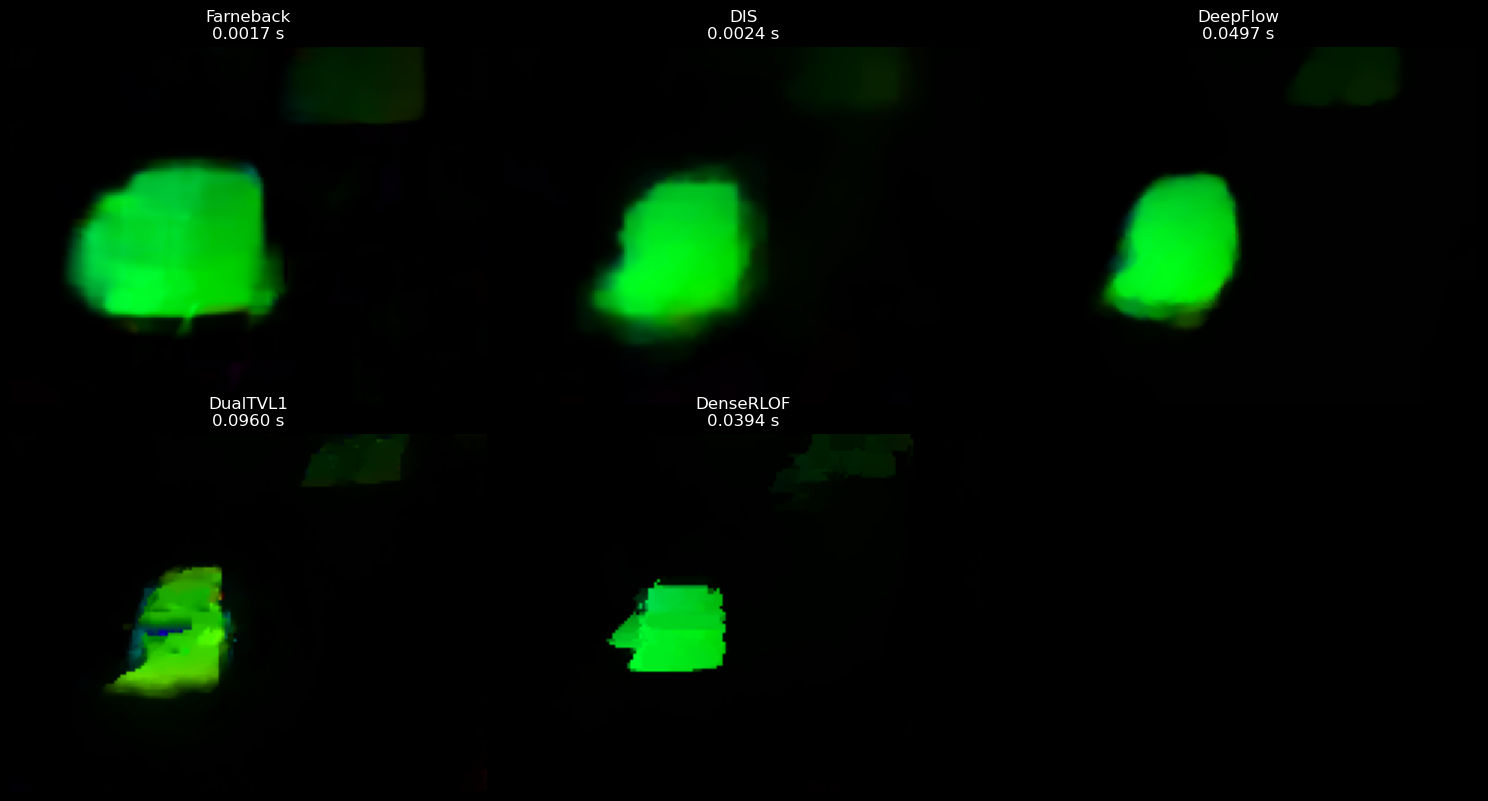

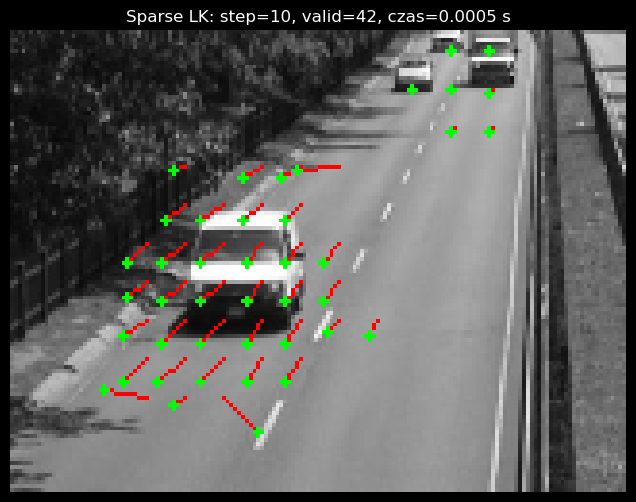

In [46]:



def dense_flow_to_rgb(flow, clip_mag=None):
    u, v = flow[..., 0], flow[..., 1]
    mag, ang = cv2.cartToPolar(u, v)
    if clip_mag is not None:
        mag = np.minimum(mag, clip_mag)

    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = (ang * 90 / np.pi).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

methods = [
    ("Farneback", lambda a, b: cv2.calcOpticalFlowFarneback(a, b, None, 0.5, 3, 15, 3, 5, 1.2, 0), None),
    ("DIS",       lambda a, b: cv2.DISOpticalFlow_create(cv2.DISOPTICAL_FLOW_PRESET_MEDIUM).calc(a, b, None), None),
    ("DeepFlow",  lambda a, b: cv2.optflow.createOptFlow_DeepFlow().calc(a, b, None), None),
    ("DualTVL1",  lambda a, b: cv2.optflow.createOptFlow_DualTVL1().calc(a, b, None), None),
    ("DenseRLOF", lambda a, b: cv2.optflow.createOptFlow_DenseRLOF().calc(cv2.cvtColor(a, cv2.COLOR_GRAY2BGR), cv2.cvtColor(b, cv2.COLOR_GRAY2BGR), None), 10),
]

results = []
for name, fn, clip in methods:
    t0 = time.time()
    flow = fn(I, J)
    dt = time.time() - t0
    rgb = dense_flow_to_rgb(flow, clip_mag=clip)
    results.append((name, dt, rgb))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.ravel()
for k, (name, dt, rgb) in enumerate(results):
    ax[k].imshow(rgb)
    ax[k].set_title(f"{name}\n{dt:.4f} s")
    ax[k].axis("off")
ax[-1].axis("off")
plt.tight_layout()

print("Zadanie 1 - czasy:")
for name, dt, _ in results:
    print(f"  {name:10s} {dt:.4f} s")


# Zadanie 2: rzadki LK na siatce
step = 10
min_mag = 1.0
lk_params = dict(
    winSize=(21, 21),
    maxLevel=3,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01),
)

h, w = I.shape
ys, xs = np.mgrid[step // 2:h:step, step // 2:w:step]
p0 = np.stack((xs, ys), axis=-1).reshape(-1, 1, 2).astype(np.float32)

t0 = time.time()
p1, st, _ = cv2.calcOpticalFlowPyrLK(I, J, p0, None, **lk_params)
dt_lk = time.time() - t0

vis = cv2.cvtColor(I, cv2.COLOR_GRAY2RGB)
valid = 0
for jj in range(p0.shape[0]):
    if st[jj, 0] == 1:
        x0, y0 = p0[jj, 0]
        x1, y1 = p1[jj, 0]
        if np.hypot(x1 - x0, y1 - y0) < min_mag:
            continue
        valid += 1
        cv2.line(vis, (int(x0), int(y0)), (int(x1), int(y1)), (255, 0, 0), 1)
        cv2.circle(vis, (int(x1), int(y1)), 1, (0, 255, 0), -1)

plt.figure(figsize=(8, 6))
plt.imshow(vis)
plt.title(f"Sparse LK: step={step}, valid={valid}, czas={dt_lk:.4f} s")
plt.axis("off")
plt.show()